In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import sys
from tqdm.auto import tqdm
from time_series import create_time_series
sys.path.insert(0, os.path.abspath("../fsrs-optimizer/src/fsrs_optimizer/"))
import numpy as np

tqdm.pandas()

In [47]:
# Review count: User id
# Median: 8798
# Most: 6810

USER_ID = 345
df = pd.read_parquet(
    "../anki-revlogs-10k/revlogs", filters=[("user_id", "=", USER_ID), ("rating", "in", [1, 2, 3, 4])], columns=["card_id", "day_offset", "rating", "elapsed_days", "duration"] 
)
df.size

96190

In [48]:
df_filtered = df[(df["elapsed_days"] > 0)]

In [49]:
groups = df_filtered.groupby("rating")["duration"].median()

df_filtered["review_average"] = df_filtered["rating"].map(groups)

current_residual = df_filtered.groupby("rating").apply(lambda x: abs(x["duration"] - x["review_average"]).mean())

current_residual, groups

/tmp/ipykernel_116203/2144162587.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["review_average"] = df_filtered["rating"].map(groups)
/tmp/ipykernel_116203/2144162587.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  current_residual = df_filtered.groupby("rating").apply(lambda x: abs(x["duration"] - x["review_average"]).mean())


(rating
 1    14399.558447
 2    15274.703969
 3    14065.750765
 4     9077.042254
 dtype: float64,
 rating
 1    33456.5
 2    31002.0
 3    18915.0
 4    10215.0
 Name: duration, dtype: float64)

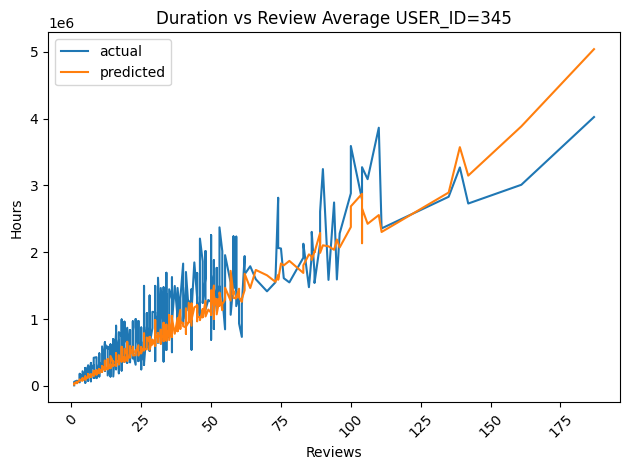

In [50]:
import matplotlib.pyplot as plt

# Group by day_offset
day_accuracies = df_filtered.groupby("day_offset")[["duration", "review_average"]]

# Compute count and sum
counts = day_accuracies.count()
sums = day_accuracies.sum()

# Sort by count of 'duration' (or 'review_average' – whichever makes sense)
sorted_indices = counts["duration"].sort_values().index

# Reorder both sums and counts to match
counts = counts.loc[sorted_indices]
sums = sums.loc[sorted_indices]

# Plot
plt.plot(counts["duration"], sums["duration"], label="actual")
plt.plot(counts["review_average"], sums["review_average"], label="predicted")

plt.xlabel("Reviews")
plt.ylabel("Hours")
plt.title(f"Duration vs Review Average {USER_ID=}")
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()


array([-0.00480439,  1.47697381])

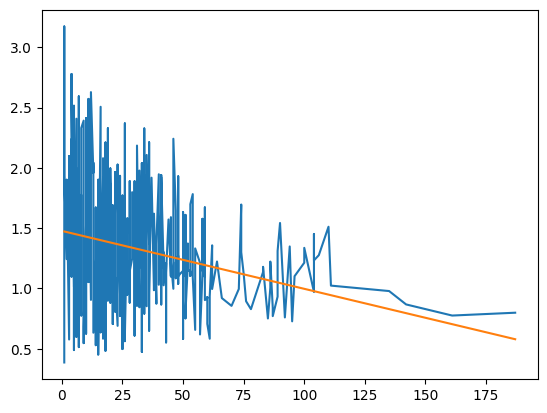

In [51]:
import numpy as np

error = sums["duration"] / sums["review_average"]
plt.plot(counts["review_average"], error, label="error")
c = np.polyfit(counts["review_average"], error, 1)
adjustment = np.polyval(c, counts["review_average"])
plt.plot(counts["review_average"], adjustment, label="adjustment")
c

(np.float64(238983.53524229076), np.float64(219051.24438930373))

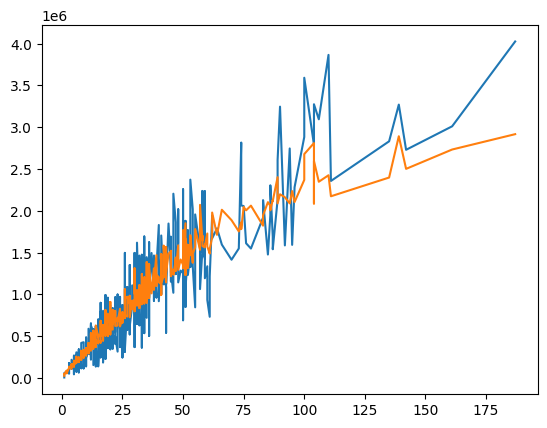

In [52]:
plt.plot(counts["duration"], sums["duration"], label="actual")
plt.plot(counts["review_average"], sums["review_average"] * adjustment, label="predicted")

(abs(sums["duration"] - sums["review_average"])).mean(), (abs(sums["duration"] - (sums["review_average"]) * adjustment)).mean()